# Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

**Scenario.** A fish-export cooperative in Jinja wants to know (a) whether its harvesting rate is sustainable and (b)
how risky its revenue is. The previous version of this question modelled stock with Fibonacci numbers and flagged risk
when revenue variance exceeded 50,000. Both ideas are replaced here with defensible models.

Code: `src/fishery/`: `stock.py` (`FishStock`, `ClosedSeasonFishStock`), `price.py` (`PriceModel`), `risk.py`
(`RiskAssessor`), `cooperative.py` (composition of stock + price, scenario runner) and `plotting.py`.

**Units and assumptions.** Time step = 1 week; stock and catch in tonnes; price in UGX/kg; revenue in UGX. The growth
rate $r = 0.4$ is interpreted *per week*, as the brief specifies 52 weekly steps. Catch is converted at 1 t = 1,000 kg
and priced at that week's price.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.plotting import apply_style
from src.core.sequences import fibonacci_numbers
from src.fishery import (
    ClosedSeasonFishStock, CooperativeModel, FishStock, PriceModel, RiskAssessor, run_scenarios,
)
from src.fishery.plotting import plot_revenue_distribution, plot_stock_trajectories

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SEED = 2026
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

## 1. Baseline: Fibonacci "stock"

In [2]:
fib_stock = fibonacci_numbers(15)
print(fib_stock)
print("successive ratios:", np.round(np.array(fib_stock[1:]) / np.array(fib_stock[:-1]), 3))

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]
successive ratios: [1.    2.    1.5   1.667 1.6   1.625 1.615 1.619 1.618 1.618 1.618 1.618
 1.618 1.618]


**Why unbounded Fibonacci growth is biologically unrealistic.** The Fibonacci recurrence $N_{t+1} = N_t + N_{t-1}$
grows geometrically forever. Its growth factor converges to $\varphi \approx 1.618$ however large the population
already is. Real fish populations are limited by food, oxygen, spawning habitat and predation, so per-capita growth
*falls* as the stock approaches the lake's carrying capacity (density dependence). The recurrence also has no mortality,
no fishing term and no environmental variability, so it cannot answer the question the cooperative actually asks:
how much can be harvested without depleting the stock. Finally, its numbers have no units or calibration to the
Lake Victoria fishery. They are a pure counting sequence, not a model of biomass.

## 2. `FishStock`: discrete logistic growth with harvesting

The model is the discrete-time form of Verhulst's (1838) logistic equation with a proportional harvest, i.e. the
Schaefer (1954) surplus-production model used in fisheries science:

$$N_{t+1} = N_t + rN_t\left(1-\frac{N_t}{K}\right) - hN_t, \qquad r=0.4,\ K=10{,}000\text{ t},\ N_0=4{,}000\text{ t}.$$

Setting $N_{t+1}=N_t$ gives the non-trivial equilibrium $N^* = K(1-h/r)$ and sustained yield $Y^* = hN^* = hK(1-h/r)$.
This is maximised at $h = r/2$, giving the **maximum sustainable yield** (Clark, 1990, ch. 1) $\text{MSY} = rK/4 = 1{,}000$ t/week.

In [3]:
stock = FishStock(r=0.4, carrying_capacity=10_000, initial_stock=4_000, harvest_rate=0.10)
traj = stock.simulate(52)
print(stock)
print(f"Hand check week 1: 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = {4000 + 0.4*4000*0.6 - 400:.0f}; model = {traj.biomass[1]:.0f}")
print(f"After 52 weeks: stock {traj.final_stock:,.1f} t (analytic N* = {stock.equilibrium_stock:,.0f} t), "
      f"total catch {traj.total_harvest:,.0f} t")
pd.DataFrame({"stock (t)": traj.biomass[:-1], "catch (t)": traj.harvest}).iloc[[0, 1, 2, 5, 10, 20, 51]]

FishStock(r=0.4, K=10,000, N0=4,000, h=0.1)
Hand check week 1: 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = 4560; model = 4560
After 52 weeks: stock 7,500.0 t (analytic N* = 7,500 t), total catch 37,363 t


,stock (t),catch (t)
0,"4,000.000",400.000
1,"4,560.000",456.000
2,"5,096.256",509.626
5,"6,371.379",637.138
10,"7,271.196",727.120
20,"7,493.253",749.325
51,"7,500.000",750.000


## 3. `PriceModel` and weekly revenue

The price is a seeded Gaussian random walk starting at UGX 12,000/kg with weekly steps of σ = UGX 400 (about 3 % of
the price). It is **reflected** at UGX 9,000 and 16,000. Reflection is used rather than clipping because clipping
makes the price stick at a bound for several weeks. Weekly revenue = catch (kg) × price.

In [4]:
prices = PriceModel(start=12_000, lower=9_000, upper=16_000, step_sd=400, seed=SEED)
coop = CooperativeModel(stock, prices)
sim = coop.simulate(52)
print(prices)
print(f"price range over the year: {sim.prices.min():,.0f} – {sim.prices.max():,.0f} UGX/kg")
print(f"week-1 revenue check: {sim.trajectory.harvest[0]:.0f} t × 1000 × {sim.prices[0]:,.0f} = UGX {sim.weekly_revenue[0]:,.0f}")
print(f"annual revenue: UGX {sim.total_revenue/1e9:,.1f} billion")

PriceModel(start=12,000, bounds=(9,000, 16,000), step_sd=400, seed=2026)
price range over the year: 11,020 – 15,694 UGX/kg
week-1 revenue check: 400 t × 1000 × 12,000 = UGX 4,800,000,000
annual revenue: UGX 460.4 billion


## 4. Revenue statistics and why a variance threshold of 50,000 is meaningless

In [5]:
risk = RiskAssessor(sim.weekly_revenue)
s = risk.stats
pd.Series({"mean (UGX)": s.mean, "median (UGX)": s.median, "variance (UGX²)": s.variance,
           "std dev (UGX)": s.stdev, "CV (unitless)": risk.cv}).to_frame("weekly revenue").style.format("{:,.3g}")

,weekly revenue
mean (UGX),8.85e+09
median (UGX),8.89e+09
variance (UGX²),1.79e+18
std dev (UGX),1.34e+09
CV (unitless),0.151


In [6]:
print(f"Variance = {s.variance:.3e} UGX²  ->  {s.variance / 50_000:.1e} times the old 50,000 threshold")
print(f"A variance of 50,000 UGX² is a standard deviation of only UGX {np.sqrt(50_000):,.0f}, "
      f"i.e. {np.sqrt(50_000)/s.mean:.1e} of mean weekly revenue.")
usd = 1 / 3_700  # illustrative exchange rate
print(f"Same revenues in USD: variance = {s.variance*usd**2:.3e} USD²; same risk, a {1/usd**2:.1e}× smaller number.")

Variance = 1.793e+18 UGX²  ->  3.6e+13 times the old 50,000 threshold
A variance of 50,000 UGX² is a standard deviation of only UGX 224, i.e. 2.5e-08 of mean weekly revenue.
Same revenues in USD: variance = 1.310e+11 USD²; same risk, a 1.4e+07× smaller number.


**Variance is measured in squared currency (UGX²).** A threshold like "50,000" therefore has no fixed meaning: it
corresponds to a standard deviation of only UGX 224, less than the price of 20 g of fish. Any realistic revenue stream
exceeds it by about 15 orders of magnitude, so the old rule would flag every business as risky. The value also
changes with the currency (UGX² vs USD²) and with the size of the business: doubling the catch quadruples the variance
while the relative risk stays the same. The **coefficient of variation** $CV = \sigma/\mu$ is dimensionless and
scale-free, so it can be compared across scenarios, currencies and cooperatives.

## 5. `RiskAssessor`: CV-based rating and Monte Carlo Value-at-Risk

**Rating rule** (thresholds justified in the class docstring). Under a normal approximation, about 95 % of weeks fall
within $\pm2\,CV$ of the mean:

| CV of weekly revenue | Rating | Meaning for the cooperative |
|---|---|---|
| < 0.10 | Low | 95 % of weeks within ±20 % of the mean, absorbable by normal working capital |
| 0.10 – 0.25 | Moderate | swings up to ±50 %; needs a cash reserve or forward contracts |
| ≥ 0.25 | High | a typical week can lose a quarter of its revenue |

**VaR.** 1,000 independent price paths are simulated for the same (deterministic) catch. The 5 % VaR is the shortfall
of the 5th-percentile annual revenue below the expected annual revenue, a Monte Carlo VaR in the sense of
Jorion (2007).

In [7]:
annual = coop.simulate_total_revenue(52, n_paths=1_000, rng=np.random.default_rng(SEED))
var95 = RiskAssessor.value_at_risk(annual, confidence=0.95)
print(f"Risk rating (h = {stock.harvest_rate}): {risk.classify().value}  (CV = {risk.cv:.3f})")
print(f"Expected annual revenue: UGX {var95.expected/1e9:,.1f} bn")
print(f"5th percentile:          UGX {var95.quantile/1e9:,.1f} bn")
print(f"5% VaR:                  UGX {var95.var/1e9:,.1f} bn  ({var95.var/var95.expected:.1%} of expected revenue)")

Risk rating (h = 0.1): Moderate  (CV = 0.151)
Expected annual revenue: UGX 451.1 bn
5th percentile:          UGX 379.0 bn
5% VaR:                  UGX 72.2 bn  (16.0% of expected revenue)


## 6. Scenario analysis: h = 0.05, 0.10, 0.20, 0.30

Every scenario is priced on the **same** 1,000 seeded price paths (common random numbers). Differences between rows
are then caused by the harvest policy, not by sampling noise.

In [8]:
H = [0.05, 0.10, 0.20, 0.30]
scenarios = run_scenarios(H, prices=prices, weeks=52, n_paths=1_000, seed=SEED)
scen_df = pd.DataFrame([s.row() for s in scenarios]).set_index("h")
scen_df

,final stock (t),equilibrium stock (t),mean weekly catch (t),equilibrium yield (t/wk),yield / MSY,total revenue (UGX bn),CV weekly revenue,risk,CV annual revenue (MC),5% VaR (UGX bn)
h,,,,,,,,,,
0.050,"8,750.000","8,750.000",417.589,437.500,0.438,267.603,0.164,Moderate,0.110,42.081
0.100,"7,500.000","7,500.000",718.510,750.000,0.750,460.357,0.151,Moderate,0.109,72.164
0.200,"4,999.988","5,000.000",978.302,"1,000.000",1.000,626.140,0.109,Moderate,0.108,96.053
0.300,"2,503.717","2,500.000",816.558,750.000,0.750,520.052,0.119,Moderate,0.101,75.488


In [9]:
msy = scenarios[0].msy
print(f"MSY = rK/4 = 0.4 × 10,000 / 4 = {msy:,.0f} t/week, achieved at h = r/2 = {stock.msy_harvest_rate}")
for s in scenarios:
    status = "at MSY" if np.isclose(s.harvest_rate, 0.2) else ("under-fished" if s.harvest_rate < 0.2 else "growth-overfished")
    print(f"h={s.harvest_rate:.2f}: sustained yield {s.equilibrium_yield:7,.1f} t/wk = {s.equilibrium_yield/msy:4.0%} of MSY, "
          f"stock → {s.equilibrium_stock:6,.0f} t ({status})")

MSY = rK/4 = 0.4 × 10,000 / 4 = 1,000 t/week, achieved at h = r/2 = 0.2
h=0.05: sustained yield   437.5 t/wk =  44% of MSY, stock →  8,750 t (under-fished)
h=0.10: sustained yield   750.0 t/wk =  75% of MSY, stock →  7,500 t (under-fished)
h=0.20: sustained yield 1,000.0 t/wk = 100% of MSY, stock →  5,000 t (at MSY)
h=0.30: sustained yield   750.0 t/wk =  75% of MSY, stock →  2,500 t (growth-overfished)


**Interpretation against MSY.**
* $h = 0.20 = r/2$ reaches MSY exactly. The stock settles at $K/2 = 5{,}000$ t and yields 1,000 t/week, the highest
  sustainable catch and revenue.
* $h = 0.05$ and $0.10$ are **under-exploited**: the stock stays large, but the cooperative forgoes 56 % and 25 % of
  the sustainable catch.
* $h = 0.30$ is **growth-overfished**. In year 1 it earns *more* than $h=0.10$ because it mines the initial stock, but
  the stock is driven down to 2,500 t and the sustained yield falls back to 75 % of MSY. It gives the same long-run catch
  as $h=0.10$ from a stock three times smaller, which leaves far less buffer against a bad recruitment year.
* All four rates are below $r$, so none of them collapses the stock in this deterministic model. Collapse needs
  $h \ge r = 0.4$.

**Risk classes.** All four scenarios rate **Moderate** (weekly CV 0.11–0.16), so harvest rate does not change the
risk class. The weekly-revenue CV also mixes two different things: price volatility, and the *transient* as the stock
moves from 4,000 t towards its equilibrium. That is why $h = 0.20$, whose equilibrium (5,000 t) is closest to $N_0$,
has the lowest weekly CV, and $h = 0.05$, whose stock more than doubles, has the highest. The Monte Carlo CV of
*annual* revenue isolates pure price risk and is almost identical across scenarios (~10–11 %), because every price
path multiplies the same catch profile. The 5 % VaR is ~15 % of expected annual revenue in each scenario: a bad year
costs UGX 42–96 bn depending on scale. Price risk can be managed through marketing (forward contracts, cold storage
to time sales), while stock risk depends on the harvest policy. A single variance threshold does not separate the two.

## 7. Visualisations

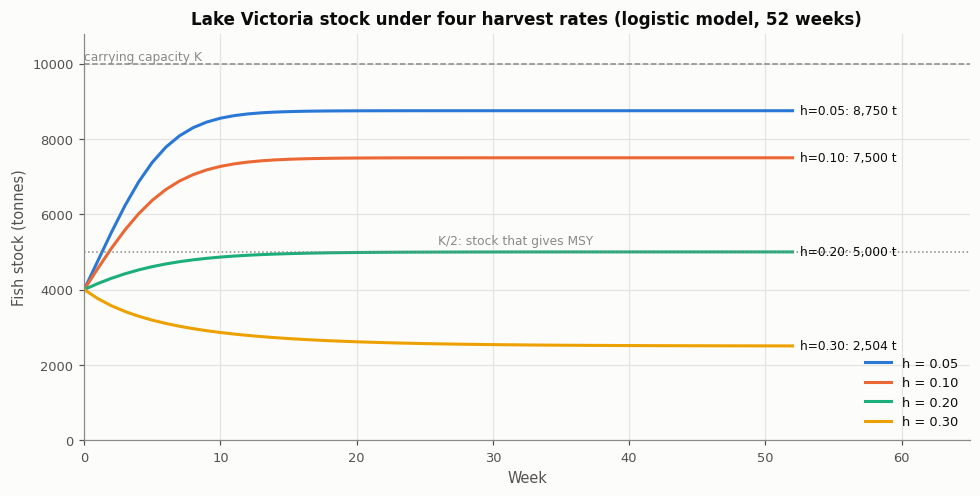

In [10]:
fig = plot_stock_trajectories(scenarios, carrying_capacity=10_000)
fig.savefig(FIG_DIR / "p3_stock_trajectories.png", bbox_inches="tight")
plt.show()

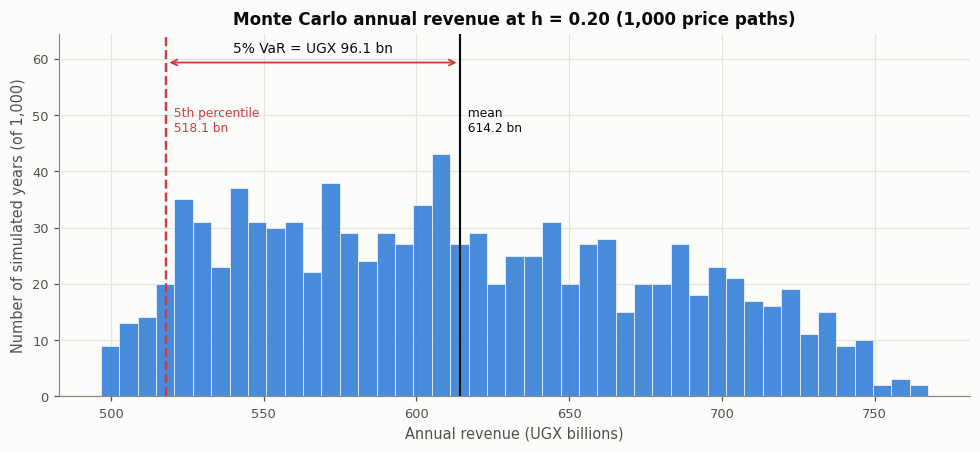

In [11]:
msy_scenario = next(s for s in scenarios if np.isclose(s.harvest_rate, 0.20))
fig = plot_revenue_distribution(msy_scenario)
fig.savefig(FIG_DIR / "p3_revenue_var.png", bbox_inches="tight")
plt.show()

## Extension: an 8-week closed season over 5 years

`ClosedSeasonFishStock` subclasses `FishStock` and overrides a single hook, `harvest_rate_at(week)`, which returns zero
during weeks 14–21 of each year (roughly April–May, a common breeding-season closure window). Both variants run for
260 weeks on the same 1,000 price paths.

In [12]:
CLOSED = range(14, 22)
YEARS5 = 5 * 52
rows = []
for h in H:
    open_model = CooperativeModel(FishStock(harvest_rate=h), prices)
    closed_model = CooperativeModel(ClosedSeasonFishStock(CLOSED, harvest_rate=h), prices)
    rev_open = open_model.simulate_total_revenue(YEARS5, 1_000, rng=np.random.default_rng(SEED))
    rev_closed = closed_model.simulate_total_revenue(YEARS5, 1_000, rng=np.random.default_rng(SEED))
    t_open, t_closed = open_model.stock.simulate(YEARS5), closed_model.stock.simulate(YEARS5)
    rows.append({"h": h,
                 "5-yr revenue open (UGX bn)": rev_open.mean() / 1e9,
                 "5-yr revenue closed season (UGX bn)": rev_closed.mean() / 1e9,
                 "revenue change %": 100 * (rev_closed.mean() / rev_open.mean() - 1),
                 "min stock open (t, yrs 2–5)": t_open.biomass[52:].min(),
                 "min stock closed (t, yrs 2–5)": t_closed.biomass[52:].min(),
                 "5-yr catch open (kt)": t_open.total_harvest / 1e3,
                 "5-yr catch closed (kt)": t_closed.total_harvest / 1e3})
closed_df = pd.DataFrame(rows).set_index("h")
closed_df

,5-yr revenue open (UGX bn),5-yr revenue closed season (UGX bn),revenue change %,"min stock open (t, yrs 2–5)","min stock closed (t, yrs 2–5)",5-yr catch open (kt),5-yr catch closed (kt)
h,,,,,,,
0.050,"1,399.485","1,192.900",-14.762,"8,750.000","8,750.000",112.715,96.026
0.100,"2,400.767","2,071.901",-13.698,"7,500.000","7,500.000",193.363,166.791
0.200,"3,213.673","2,915.429",-9.280,"4,999.988","5,000.111",258.872,234.747
0.300,"2,462.102","2,640.381",7.241,"2,500.000","2,515.133",198.472,212.732


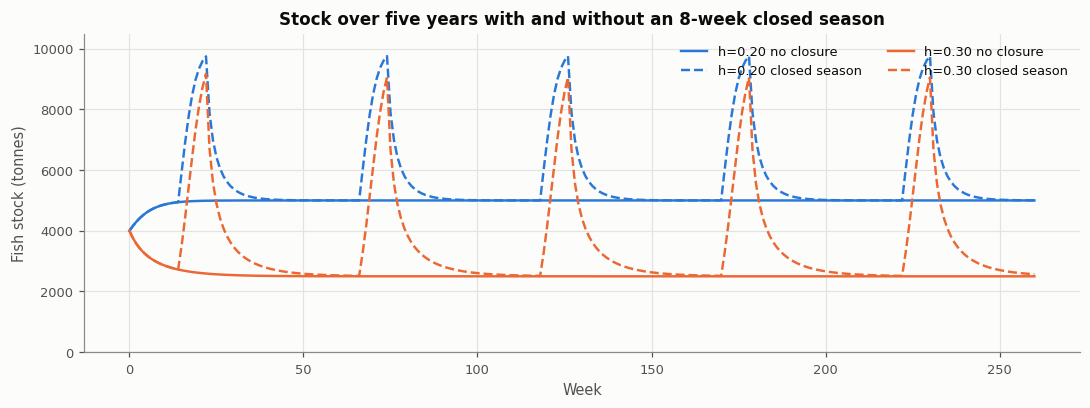

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for i, h in enumerate([0.20, 0.30]):
    for cls, ls in ((FishStock(harvest_rate=h), "-"), (ClosedSeasonFishStock(CLOSED, harvest_rate=h), "--")):
        b = cls.simulate(YEARS5).biomass
        ax.plot(b, ls=ls, color=f"C{i}", lw=1.6,
                label=f"h={h:.2f} {'closed season' if ls == '--' else 'no closure'}")
ax.set_xlabel("Week"); ax.set_ylabel("Fish stock (tonnes)"); ax.set_ylim(0, 10_500)
ax.set_title("Stock over five years with and without an 8-week closed season")
ax.legend(ncol=2, loc="upper right")
fig.tight_layout(); plt.show()

**Effect of the closed season.** During the 8-week closure the stock rebuilds towards $K$, and when fishing resumes
the catch comes from a larger stock. Whether that repays the lost weeks depends on where the stock sits relative to
$K/2$, the most productive level:
* At **$h \le 0.20$** the stock is already at or above $K/2$, where surplus growth is *falling*. The rebuilt biomass
  adds little growth, and 5-year revenue drops 9–15 %. In this model the closure only costs revenue.
* At **$h = 0.30$** (overfished, stock ≈ 2,500 t) the closure moves the stock towards the more productive $K/2$ region.
  Catch *and* revenue rise by ~7 % over five years, even though boats are idle for 15 % of the year. The late-season
  stock trough barely moves (~2,515 t vs 2,500 t), because the high harvest rate removes the rebuilt biomass quickly
  once fishing reopens.

So under the deterministic logistic model a closed season only pays when the fishery is overfished. For a well-managed
fishery its case rests on things the model leaves out: protecting spawning aggregations and juveniles (age
structure), and insurance against recruitment failure. The larger effect on revenue comes from setting $h$ close to $r/2$.

## References

* Clark, C. W. (1990). *Mathematical Bioeconomics: The Optimal Management of Renewable Resources* (2nd ed.). Wiley.
* Jorion, P. (2007). *Value at Risk: The New Benchmark for Managing Financial Risk* (3rd ed.). McGraw-Hill.
* Schaefer, M. B. (1954). Some aspects of the dynamics of populations important to the management of the commercial marine fisheries. *Bulletin of the Inter-American Tropical Tuna Commission*, 1(2), 27–56.
* Verhulst, P.-F. (1838). Notice sur la loi que la population suit dans son accroissement. *Correspondance mathématique et physique*, 10, 113–121.

## Findings & Limitations

**Findings.** Under the logistic model, "is our harvest rate sustainable?" has a precise answer. Any rate below
$r = 0.4$ converges to a positive stock, but only $h = r/2 = 0.20$ maximises the sustainable catch (MSY = 1,000 t/week,
about UGX 626 bn in year one). Rates of 0.05 and 0.10 leave 56 % and 25 % of that catch in the water. $h = 0.30$ looks
attractive in year one, earning 13 % more than $h = 0.10$, but only because it mines the initial stock. It then settles
on the *same* 750 t/week as $h = 0.10$ while keeping a third of the biomass, which leaves less buffer against poor recruitment. Recommendation: move towards $h \approx 0.2$.

Replacing the unit-dependent variance threshold with the CV shows that revenue risk is **Moderate in every scenario and
driven by price, not biology**. The price-only CV of annual revenue is ~10 %, and the 5 % VaR is ~15 % of expected
revenue. The harvest rate mainly determines the level of revenue, while its variability comes from prices. A closed season raises
long-run revenue only when the stock is overfished (+7 % at $h = 0.30$).

**Limitations.** Taking $r = 0.4$ per week means the stock can double within weeks. That suits fast-maturing mukene, not
slow-maturing Nile perch. The scale (hundreds of tonnes a week)
far exceeds a single cooperative's landings, so absolute UGX figures are illustrative. The stock is deterministic,
with no recruitment, hypoxia or illegal-fishing shocks. A harvest *fraction* assumes
perfect knowledge of stock size. The price ignores demand elasticity
(large landings would depress it), and without fuel and labour costs revenue is not profit, so MSY is not the economic
optimum. A 5 % VaR from 1,000 paths rests on only ~50 tail draws.